Loading Loki samples...
  Loki: (75000, 5)
Loading my QCW dL-masked samples...
  My QCW (full): (126372, 5)
  My QCW (subsampled for plots): (75000, 5)
Loading Enterprise samples...
  Enterprise: (72001, 5)

Panel 1: My QCW vs Loki


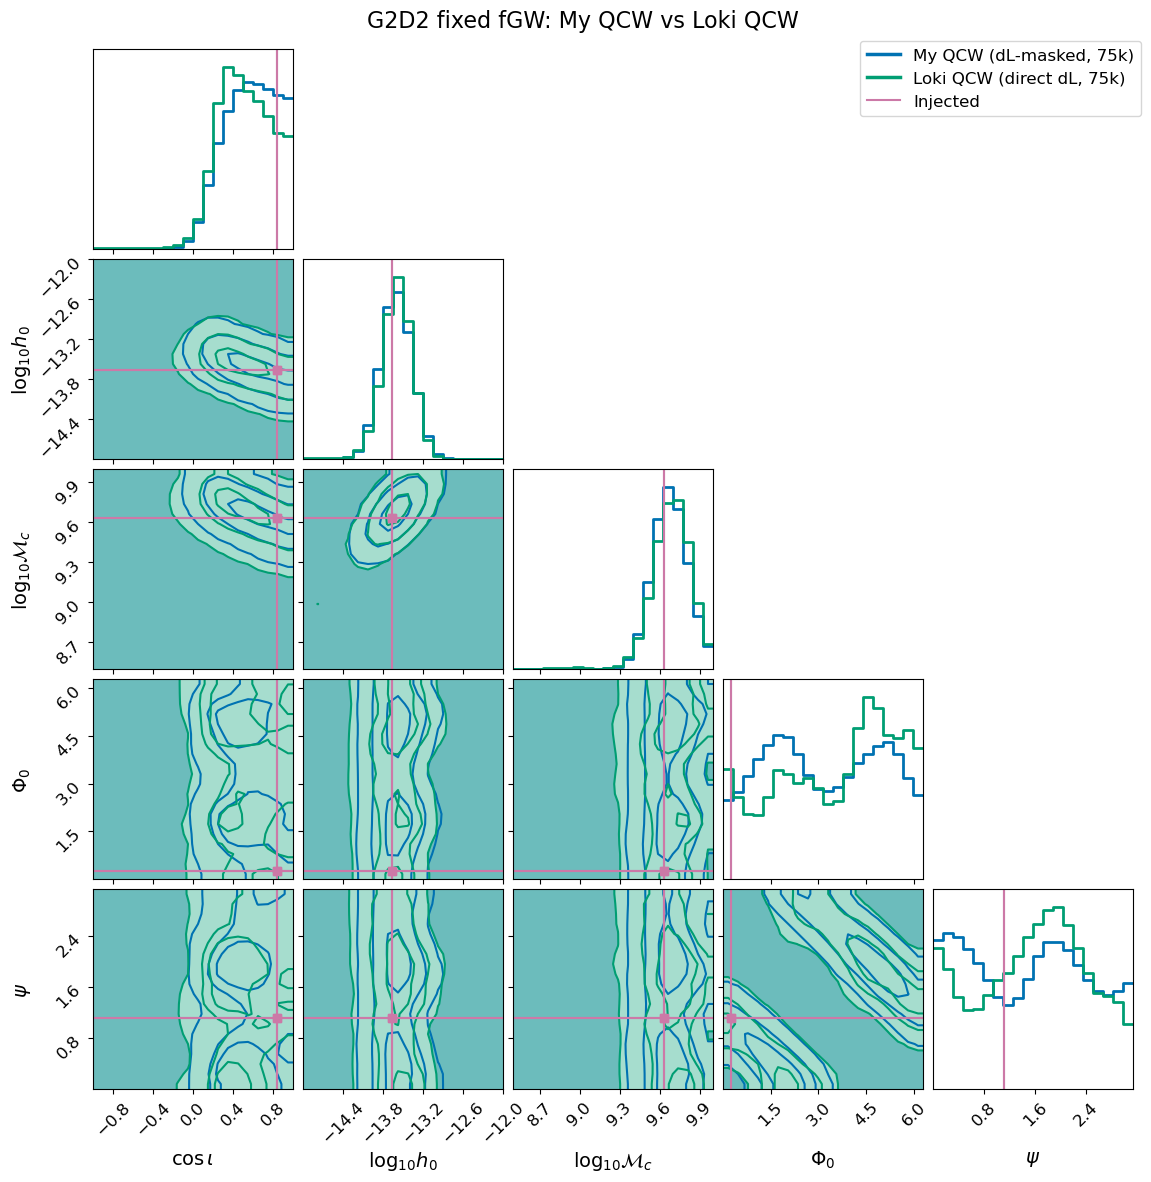

Panel 2: Loki vs Enterprise


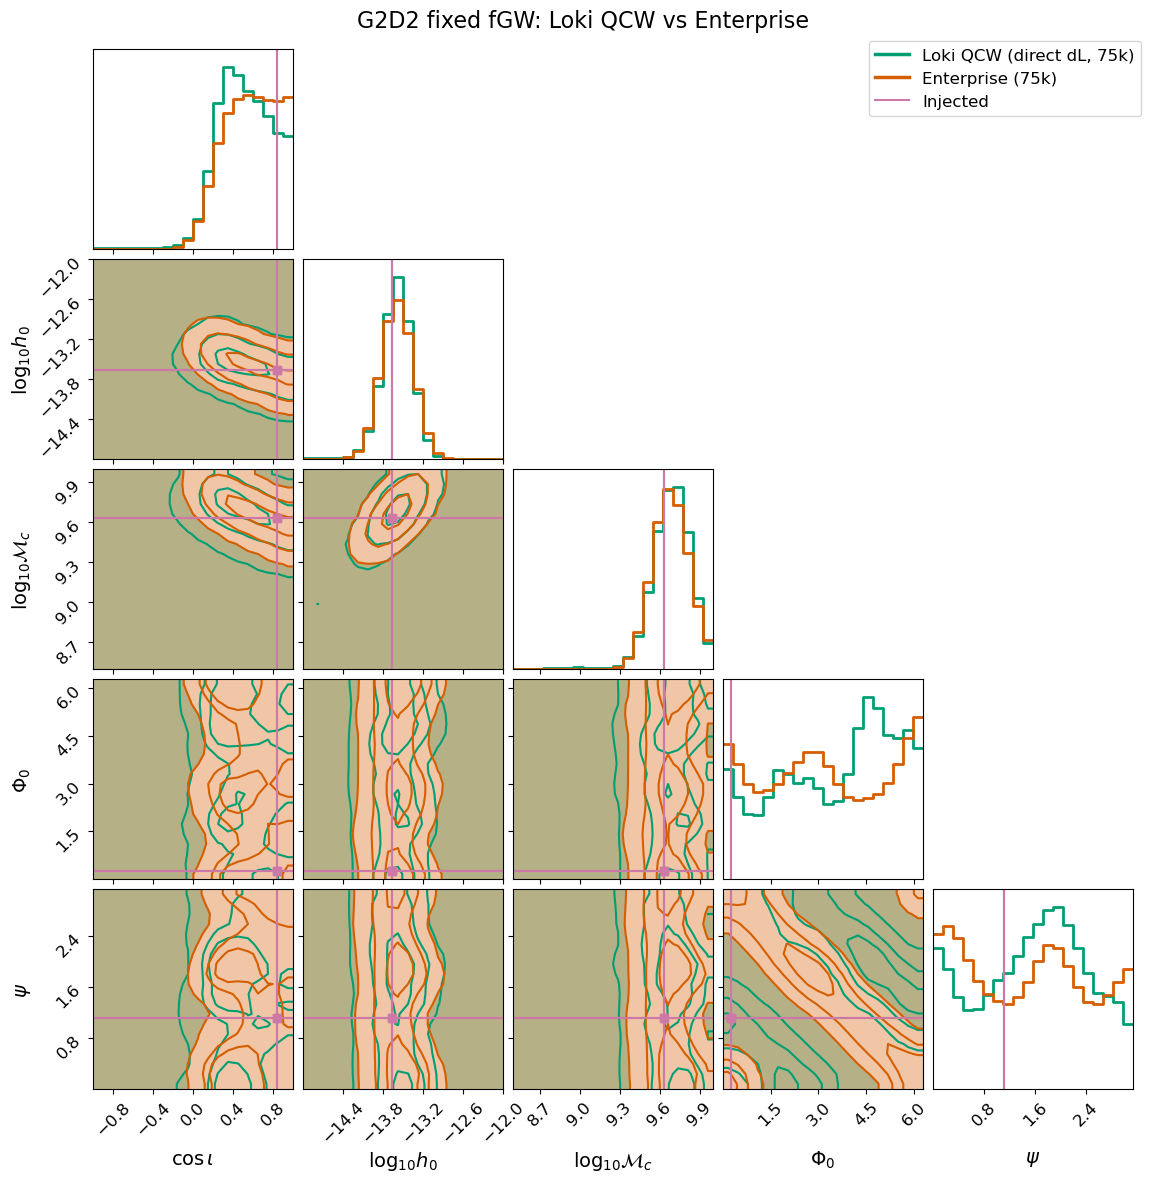

Panel 3: My QCW vs Enterprise


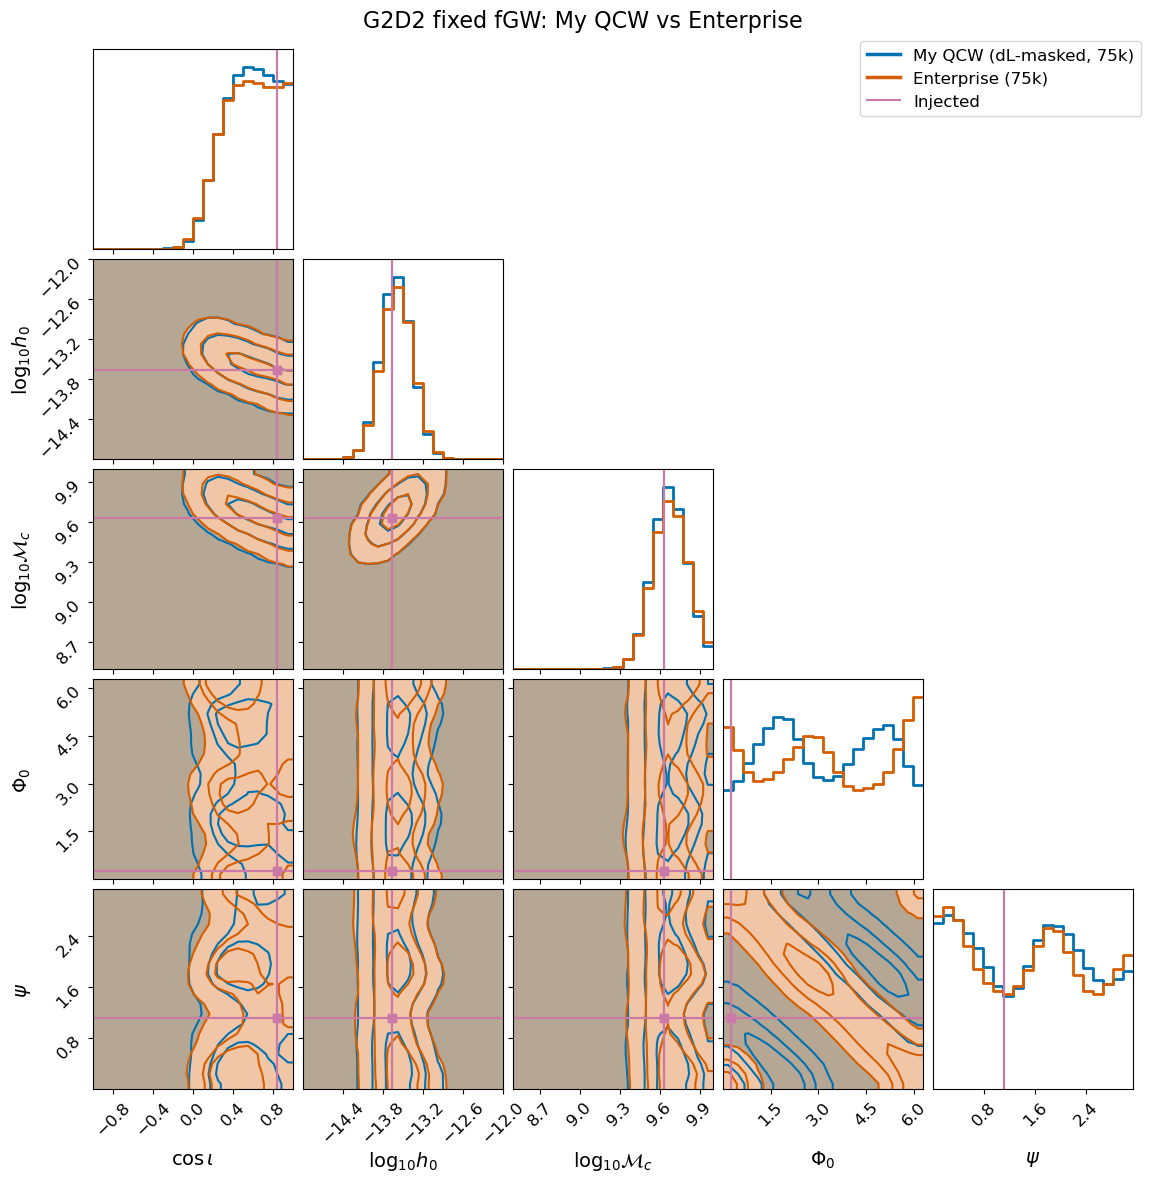

Panel 4: All three pipelines


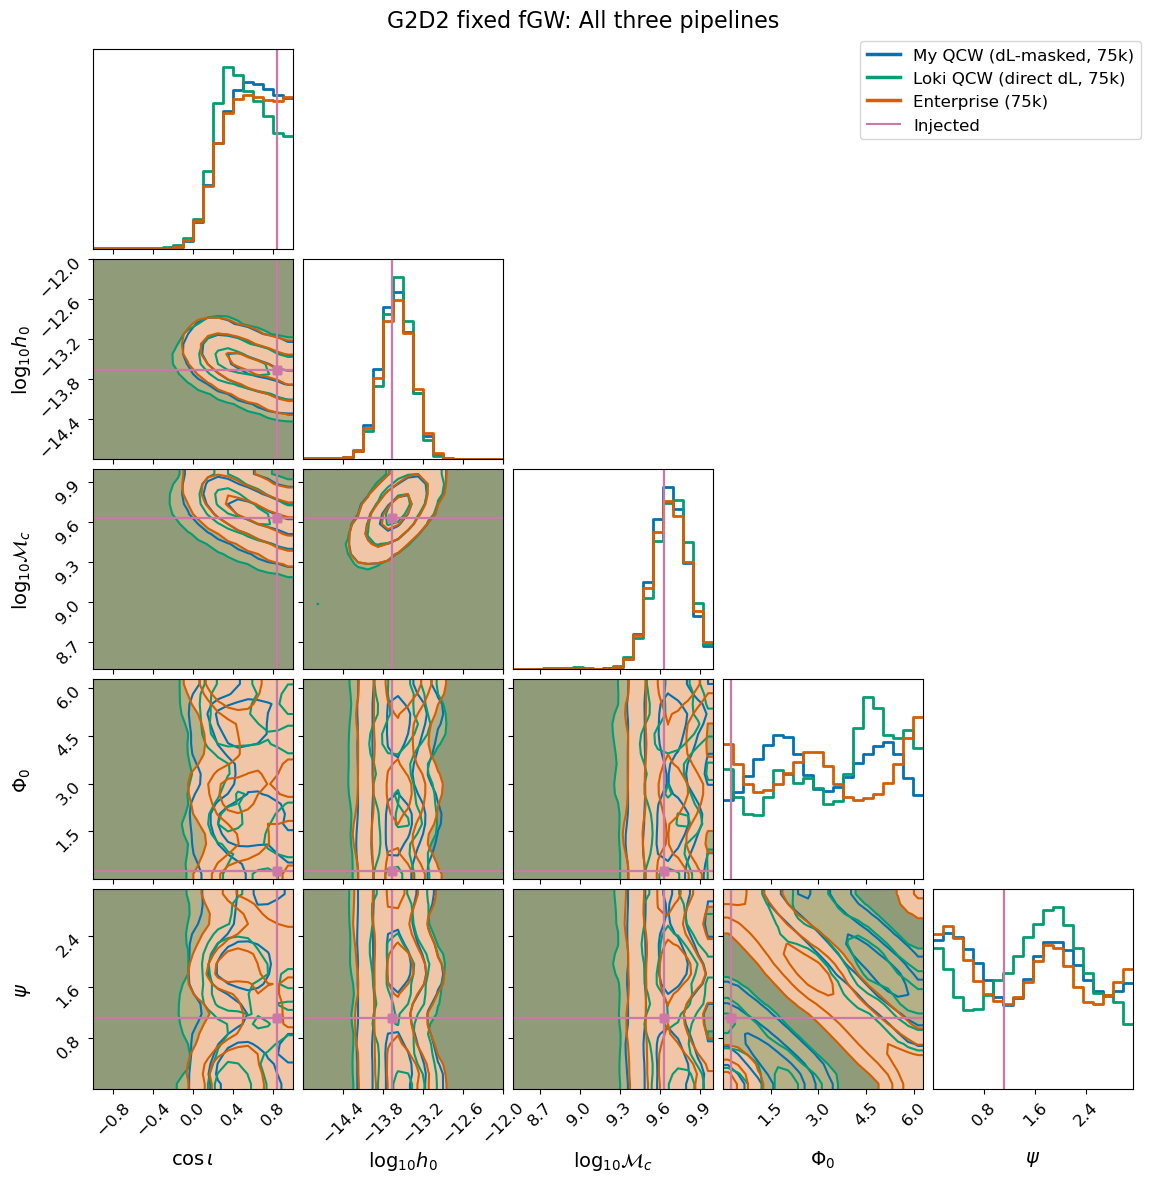


Savage-Dickey Bayes factors (FULL chains, no subsampling)
My QCW (n=126,372):     B10 = nan +/- nan
Loki   (n=75,000):     B10 = nan +/- nan
  Note: Loki log10_h0 derived; implicit prior is non-log-uniform.
Ent    (n=72,001):     B10 = nan +/- nan
  Note: Enterprise log10_h0 derived with fixed dL, fGW; same caveat.


/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:262: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:222: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:254: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/usr/local/anaconda/lib/python3.9/site-packages/enterprise_extensions/model_utils.py:194: Runti

In [1]:
# ============================================================
# G2D2 fixed fGW Detection: 2x2 comparison of three pipelines
# - My QCW subsampled to 75k for visual fairness
# - Loki and Enterprise use full chains
# - SD BF computed from FULL chains (not subsampled)
#
# 5x5 corner: cos_inc, log10_h0, log10_mc, Phi0, psi
#
# Pipelines:
#   - My QCW (dL-masked):  G2D2_narrow_detect_dLmasked_75.400Mpc.h5
#   - Loki QCW:            G2D2_fixed_detect_loki_75k_04_May_2026.h5
#   - Bjorn Enterprise:    core_single_MDC2.h5
# ============================================================

%matplotlib inline

import numpy as np
import h5py
import matplotlib.pyplot as plt
import corner
from enterprise_extensions import model_utils

plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 14

# Reproducible subsampling
np.random.seed(42)


# ============================================================
# Constants and paths
# ============================================================
C_LIGHT = 299792458.0
MPC_IN_M = 3.085677581491367e22
T_SUN = 1.327124400e20 / C_LIGHT**3

LOG10_T_SUN = np.log10(T_SUN)
LOG10_PI = np.log10(np.pi)
LOG10_C = np.log10(C_LIGHT)
LOG10_MPC = np.log10(MPC_IN_M)
LOG10_2 = np.log10(2.0)

F_GW_FIXED = 3.7e-9
D_MPC_FIXED = 75.400

LOKI_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/"
    "G2D2_fixed_detect_loki_75k_04_May_2026.h5"
)
QCW_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/"
    "G2D2_narrow_detect_dLmasked_75.400Mpc.h5"
)
ENT_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/"
    "core_single_MDC2.h5"
)

N_SUBSAMPLE = 75000


# ============================================================
# Truth, labels, ranges
# ============================================================
truth = {
    "0_cos_inc":   0.8412486994612669,
    "0_log10_h":   -13.668773493298787,
    "0_log10_mc":  np.log10(4.3e9),
    "0_phase0":    0.24434609527920614,
    "0_psi":       1.1187560505283651,
}

qc_keys = ["0_cos_inc", "0_log10_h", "0_log10_mc", "0_phase0", "0_psi"]

labels = [
    r"$\cos\iota$",
    r"$\log_{10} h_0$",
    r"$\log_{10}\mathcal{M}_c$",
    r"$\Phi_0$",
    r"$\psi$",
]

ranges = [
    (-1, 1),
    (-15, -12),
    (8.5, 10.0),
    (0, 2*np.pi),
    (0, np.pi),
]


# ============================================================
# Log-space h0 derivation
# ============================================================
def derive_log10_h0(log10_mc, log10_fgw, log10_dL_Mpc):
    return (
        LOG10_2
        + (5.0/3.0) * (log10_mc + LOG10_T_SUN)
        + (2.0/3.0) * (LOG10_PI + log10_fgw)
        - (log10_dL_Mpc + LOG10_MPC - LOG10_C)
    )


# ============================================================
# Load Loki
# ============================================================
print("Loading Loki samples...")
with h5py.File(LOKI_FILE, "r") as f:
    loki_samples = f["samples_cold"][0, :, :]
    loki_par_names = [p.decode() if isinstance(p, bytes) else p
                      for p in f["par_names"][:]]

loki_log10_mc = loki_samples[:, loki_par_names.index("0_log10_mc")]
loki_log10_fgw = loki_samples[:, loki_par_names.index("0_log10_fgw")]
loki_log10_dist = loki_samples[:, loki_par_names.index("0_log10_dist")]
loki_log10_h0 = derive_log10_h0(loki_log10_mc, loki_log10_fgw, loki_log10_dist)

loki_plot_full = np.column_stack([
    loki_samples[:, loki_par_names.index("0_cos_inc")],
    loki_log10_h0,
    loki_log10_mc,
    loki_samples[:, loki_par_names.index("0_phase0")],
    loki_samples[:, loki_par_names.index("0_psi")],
])
print(f"  Loki: {loki_plot_full.shape}")


# ============================================================
# Load my QCW (full + subsampled)
# ============================================================
print("Loading my QCW dL-masked samples...")
with h5py.File(QCW_FILE, "r") as f:
    qc_samples = f["samples_masked"][...]
    qc_par_names = [p.decode() if isinstance(p, bytes) else p
                    for p in f["par_names"][:]]

qc_plot_full = np.column_stack([qc_samples[:, qc_par_names.index(k)] for k in qc_keys])
print(f"  My QCW (full): {qc_plot_full.shape}")

# Subsample to 75k for the corner plots
sub_idx = np.random.choice(qc_plot_full.shape[0], size=N_SUBSAMPLE, replace=False)
qc_plot = qc_plot_full[sub_idx]
print(f"  My QCW (subsampled for plots): {qc_plot.shape}")


# ============================================================
# Load Enterprise
# ============================================================
print("Loading Enterprise samples...")
with h5py.File(ENT_FILE, "r") as f:
    e_samples_all = f["chain"][...]
    e_par_names = [p.decode() if isinstance(p, bytes) else p
                   for p in f["params"][:]]
    burn = f["metadata/burn"][()]
e_samples = e_samples_all[burn:, :]

ent_log10_mc = e_samples[:, e_par_names.index("log10_mc")]
ent_log10_h0 = derive_log10_h0(
    ent_log10_mc,
    np.full_like(ent_log10_mc, np.log10(F_GW_FIXED)),
    np.full_like(ent_log10_mc, np.log10(D_MPC_FIXED)),
)

ent_plot = np.column_stack([
    e_samples[:, e_par_names.index("cos_inc")],
    ent_log10_h0,
    ent_log10_mc,
    e_samples[:, e_par_names.index("phase0")],
    e_samples[:, e_par_names.index("psi")],
])
print(f"  Enterprise: {ent_plot.shape}\n")


# ============================================================
# Plot styling
# ============================================================
C_QCW   = "#0072B2"
C_LOKI  = "#009E73"
C_ENT   = "#D55E00"
C_TRUTH = "#CC79A7"


def corner_kwargs(color):
    return dict(
        color=color,
        plot_datapoints=False,
        plot_density=False,
        fill_contours=True,
        smooth=1.0,
        smooth1d=1.0,
        levels=(0.393, 0.865, 0.989),
        hist_kwargs=dict(linewidth=2.0, color=color),
        contour_kwargs=dict(linewidths=1.5, colors=[color]),
        contourf_kwargs=dict(alpha=0.35, colors=[color]),
    )


def make_panel_corner(samples_list, colors_list, labels_pipelines, panel_title):
    truth_vals = [truth[k] for k in qc_keys]

    fig = corner.corner(
        samples_list[0],
        labels=labels,
        truths=truth_vals,
        truth_color=C_TRUTH,
        range=ranges,
        show_titles=False,
        label_kwargs={"fontsize": 14},
        **corner_kwargs(colors_list[0]),
    )

    for samples, color in zip(samples_list[1:], colors_list[1:]):
        corner.corner(
            samples,
            fig=fig,
            labels=labels,
            truths=truth_vals,
            truth_color=C_TRUTH,
            range=ranges,
            show_titles=False,
            **corner_kwargs(color),
        )

    for ax in fig.get_axes():
        ax.tick_params(axis="both", labelsize=12)

    handles = [plt.Line2D([0], [0], color=c, lw=2.5, label=lab)
               for c, lab in zip(colors_list, labels_pipelines)]
    handles.append(plt.Line2D([0], [0], color=C_TRUTH, lw=1.5, label="Injected"))
    fig.legend(handles=handles, loc="upper right", fontsize=12,
               bbox_to_anchor=(0.98, 0.98), frameon=True)

    fig.suptitle(panel_title, fontsize=16, y=1.0)
    return fig


# ============================================================
# Generate four panels
# ============================================================
print("Panel 1: My QCW vs Loki")
fig1 = make_panel_corner(
    [qc_plot, loki_plot_full],
    [C_QCW, C_LOKI],
    ["My QCW (dL-masked, 75k)", "Loki QCW (direct dL, 75k)"],
    "G2D2 fixed fGW: My QCW vs Loki QCW",
)
plt.show()

print("Panel 2: Loki vs Enterprise")
fig2 = make_panel_corner(
    [loki_plot_full, ent_plot],
    [C_LOKI, C_ENT],
    ["Loki QCW (direct dL, 75k)", "Enterprise (75k)"],
    "G2D2 fixed fGW: Loki QCW vs Enterprise",
)
plt.show()

print("Panel 3: My QCW vs Enterprise")
fig3 = make_panel_corner(
    [qc_plot, ent_plot],
    [C_QCW, C_ENT],
    ["My QCW (dL-masked, 75k)", "Enterprise (75k)"],
    "G2D2 fixed fGW: My QCW vs Enterprise",
)
plt.show()

print("Panel 4: All three pipelines")
fig4 = make_panel_corner(
    [qc_plot, loki_plot_full, ent_plot],
    [C_QCW, C_LOKI, C_ENT],
    ["My QCW (dL-masked, 75k)", "Loki QCW (direct dL, 75k)", "Enterprise (75k)"],
    "G2D2 fixed fGW: All three pipelines",
)
plt.show()


# ============================================================
# SD Bayes factors using FULL chains (not subsampled)
# ============================================================
print("\n" + "="*60)
print("Savage-Dickey Bayes factors (FULL chains, no subsampling)")
print("="*60)

qcw_BF, qcw_BF_err = model_utils.bayes_fac(
    samples=qc_plot_full[:, qc_keys.index("0_log10_h")], logAmax=-11)
print(f"My QCW (n={qc_plot_full.shape[0]:,}):     B10 = {qcw_BF:.4f} +/- {qcw_BF_err:.4f}")

loki_BF, loki_BF_err = model_utils.bayes_fac(
    samples=loki_plot_full[:, qc_keys.index("0_log10_h")], logAmax=-11)
print(f"Loki   (n={loki_plot_full.shape[0]:,}):     B10 = {loki_BF:.4f} +/- {loki_BF_err:.4f}")
print("  Note: Loki log10_h0 derived; implicit prior is non-log-uniform.")

ent_BF, ent_BF_err = model_utils.bayes_fac(
    samples=ent_plot[:, qc_keys.index("0_log10_h")], logAmax=-11)
print(f"Ent    (n={ent_plot.shape[0]:,}):     B10 = {ent_BF:.4f} +/- {ent_BF_err:.4f}")
print("  Note: Enterprise log10_h0 derived with fixed dL, fGW; same caveat.")

Sanity check derive_log10_h0 at injection: -13.668773
Expected: -13.668773
Difference: -4.93e-07

Loading Loki samples...
  Loki samples: (75000, 5), log10_h0 range = [-17.995, -13.213]
Loading my QCW dL-masked samples...
  My QCW samples: (126372, 5)
Loading Enterprise samples...
  Enterprise samples: (72001, 5)

Panel 1: My QCW vs Loki


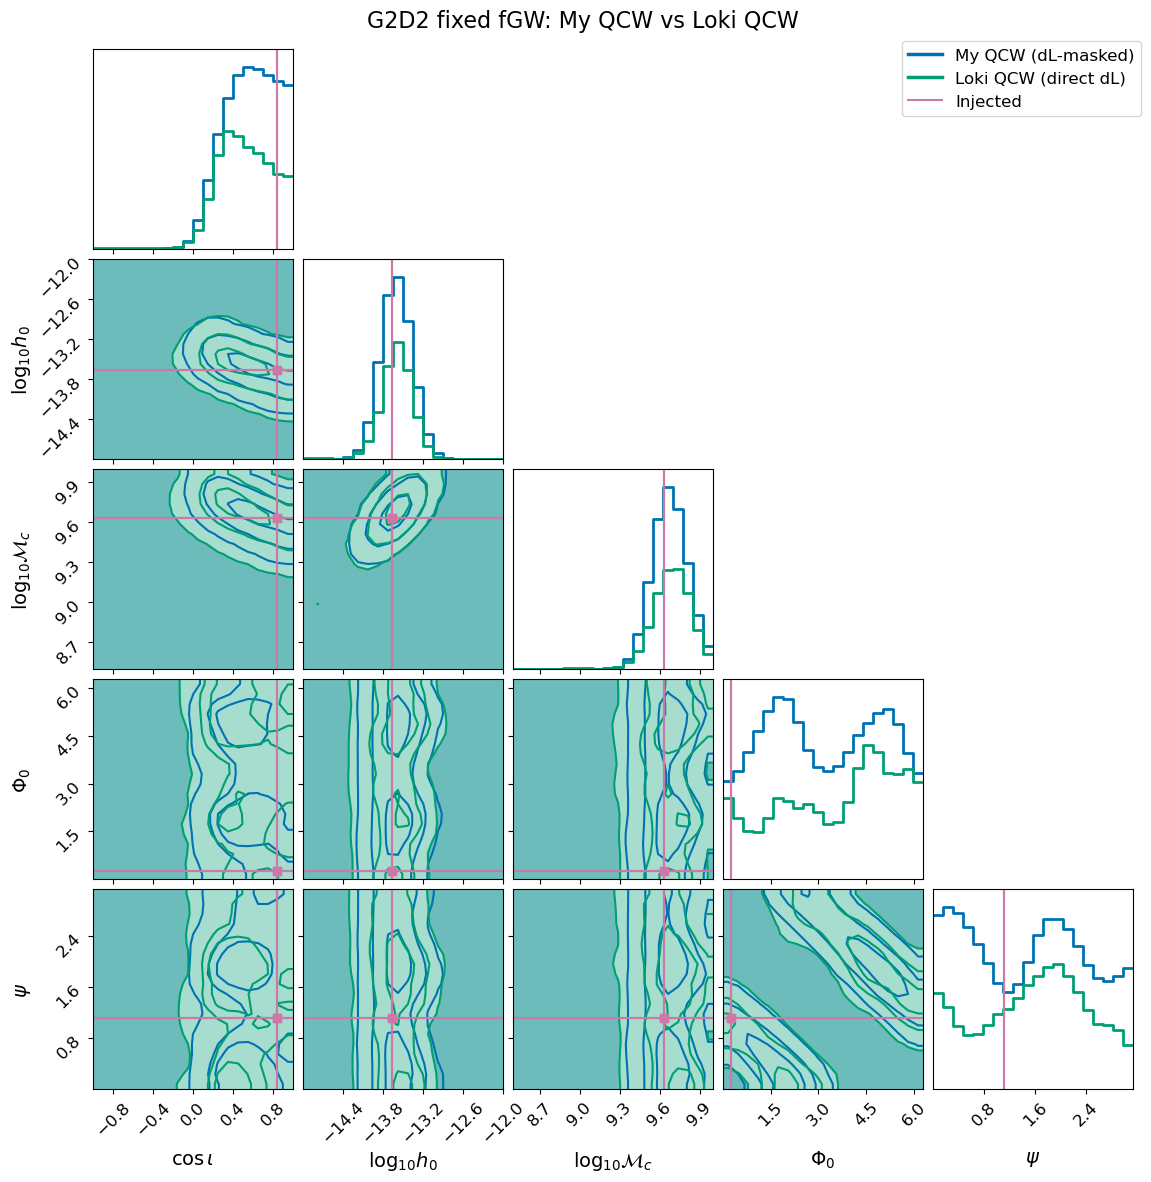

Panel 2: Loki vs Enterprise


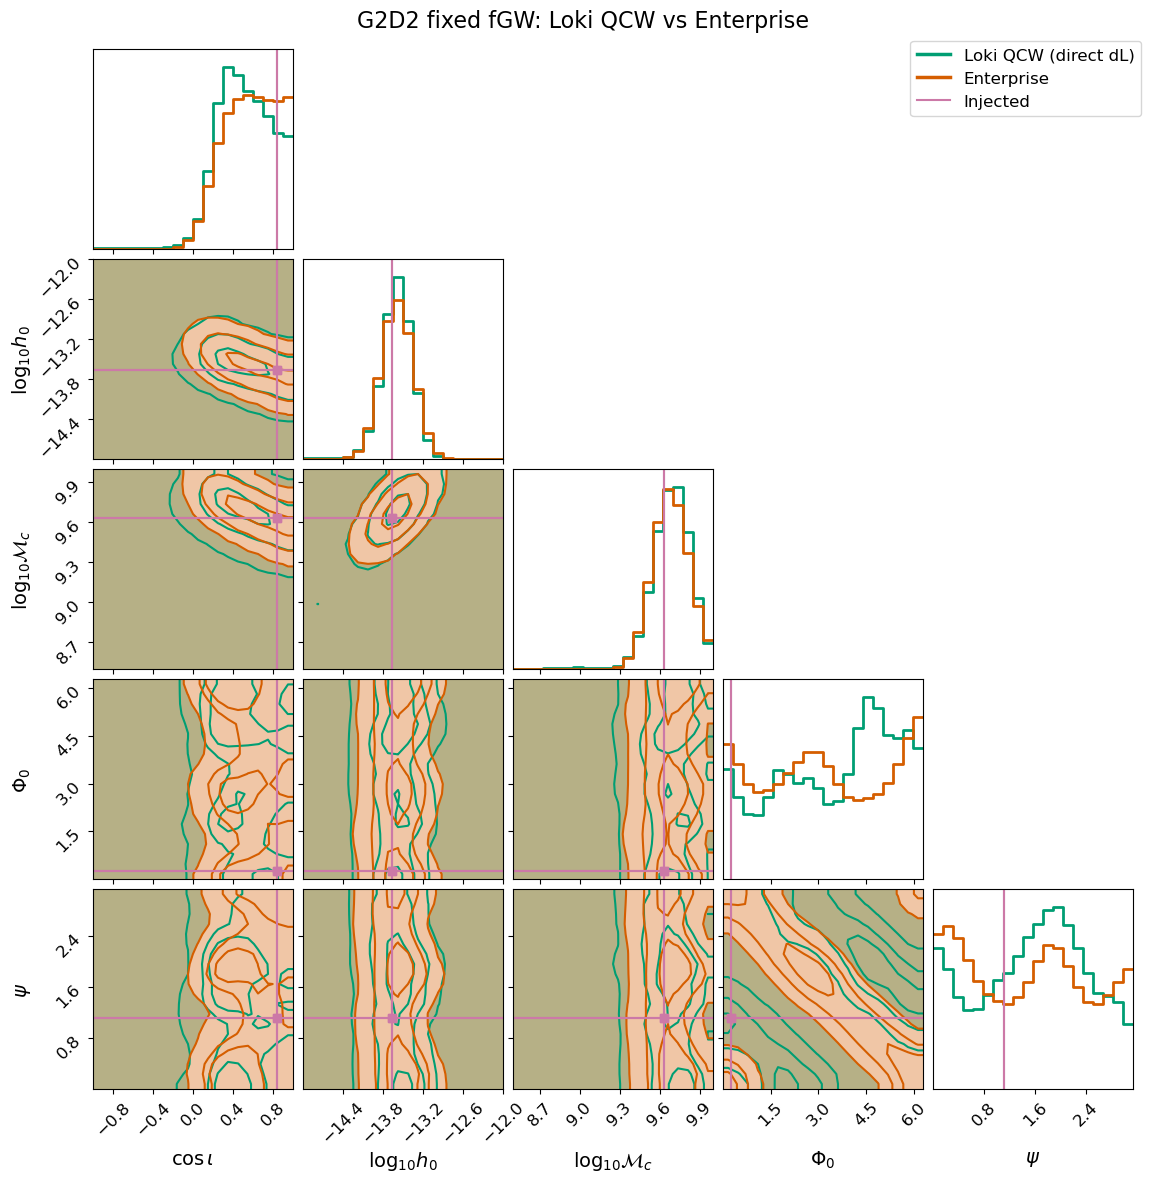

Panel 3: My QCW vs Enterprise


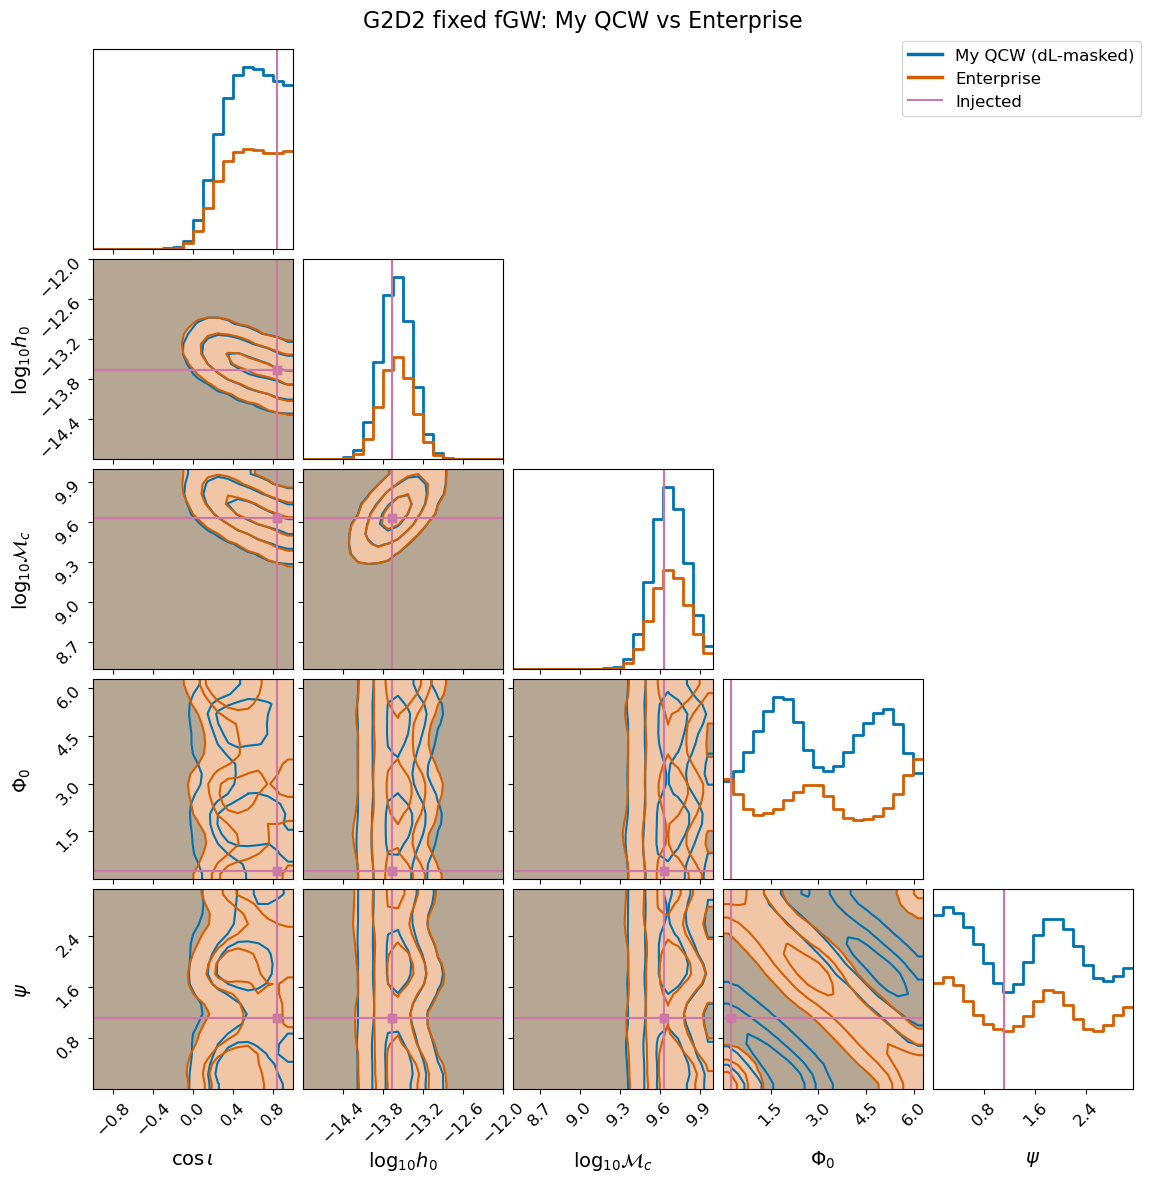

Panel 4: All three pipelines


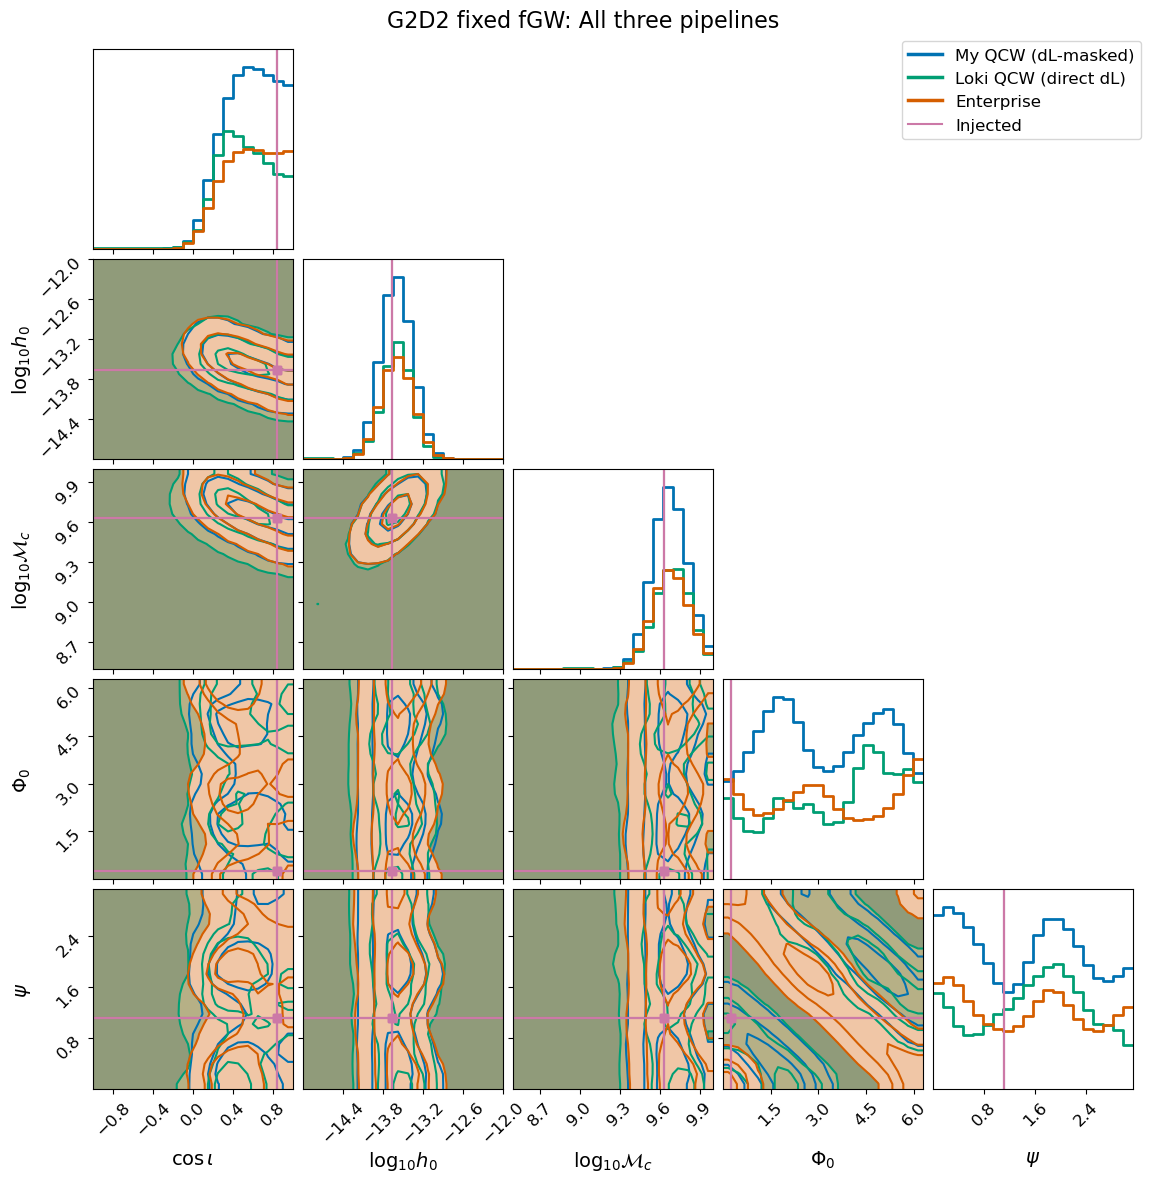


Savage-Dickey Bayes factors (full chains)
My QCW (dL-masked):   B10 = nan +/- nan
Loki QCW (direct dL): B10 = nan +/- nan
  Note: Loki log10_h0 is DERIVED. Implicit prior on h0 is non-log-uniform.
Enterprise:           B10 = nan +/- nan
  Note: Enterprise log10_h0 is DERIVED with fixed dL, fGW. Same caveat.


/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:262: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:222: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:254: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/usr/local/anaconda/lib/python3.9/site-packages/enterprise_extensions/model_utils.py:194: Runti

In [2]:
# ============================================================
# G2D2 fixed fGW Detection: comparison of three pipelines
# Cleaned up version with log-space h0 derivation and smooth
# filled contours.
#
# Pipelines:
#   - My QCW (dL-masked):  G2D2_narrow_detect_dLmasked_75.400Mpc.h5
#   - Loki QCW:            G2D2_fixed_detect_loki_75k_04_May_2026.h5
#   - Bjorn Enterprise:    core_single_MDC2.h5
#
# No burn-in applied (consistent with paper Section 5 convention
# for QuickCW runs). Enterprise burn-in is taken from its h5 metadata.
# ============================================================

%matplotlib inline

import numpy as np
import h5py
import matplotlib.pyplot as plt
import corner
from enterprise_extensions import model_utils

plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 14


# ============================================================
# Constants and paths
# ============================================================
C_LIGHT = 299792458.0                 # m/s
MPC_IN_M = 3.085677581491367e22       # m
T_SUN = 1.327124400e20 / C_LIGHT**3   # s, equals G*M_sun/c^3

# Precomputed log10 quantities for log-space h0 formula
LOG10_T_SUN = np.log10(T_SUN)         # log10 of solar mass in time units
LOG10_PI = np.log10(np.pi)
LOG10_C = np.log10(C_LIGHT)
LOG10_MPC = np.log10(MPC_IN_M)
LOG10_2 = np.log10(2.0)

# G2D2 injection parameters
F_GW_FIXED = 3.7e-9
D_MPC_FIXED = 75.400

# File paths
LOKI_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/"
    "G2D2_fixed_detect_loki_75k_04_May_2026.h5"
)
QCW_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/"
    "G2D2_narrow_detect_dLmasked_75.400Mpc.h5"
)
ENT_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/"
    "core_single_MDC2.h5"
)


# ============================================================
# Truth values
# ============================================================
truth = {
    "0_cos_inc":   0.8412486994612669,
    "0_log10_h":   -13.668773493298787,
    "0_log10_mc":  np.log10(4.3e9),
    "0_phase0":    0.24434609527920614,
    "0_psi":       1.1187560505283651,
}

qc_keys = ["0_cos_inc", "0_log10_h", "0_log10_mc", "0_phase0", "0_psi"]

labels = [
    r"$\cos\iota$",
    r"$\log_{10} h_0$",
    r"$\log_{10}\mathcal{M}_c$",
    r"$\Phi_0$",
    r"$\psi$",
]

ranges = [
    (-1, 1),
    (-15, -12),       # tighter for clearer visualization of the main mode
    (8.5, 10.0),      # tighter for chirp mass main mode
    (0, 2*np.pi),
    (0, np.pi),
]


# ============================================================
# h0 derivation in LOG SPACE (no overflow possible)
#
# h0 = 2 * (Mc * T_sun)^(5/3) * (pi * fGW)^(2/3) / (dL_Mpc * Mpc / c)
#
# log10_h0 = log10(2)
#          + (5/3) * (log10_mc + log10(T_sun))
#          + (2/3) * (log10(pi) + log10_fgw)
#          - (log10(dL_Mpc) + log10(Mpc) - log10(c))
# ============================================================
def derive_log10_h0(log10_mc, log10_fgw, log10_dL_Mpc):
    """Pure log-space derivation; numerically stable."""
    log10_h0 = (
        LOG10_2
        + (5.0/3.0) * (log10_mc + LOG10_T_SUN)
        + (2.0/3.0) * (LOG10_PI + log10_fgw)
        - (log10_dL_Mpc + LOG10_MPC - LOG10_C)
    )
    return log10_h0


# Sanity check at injection
h0_check = derive_log10_h0(np.log10(4.3e9), np.log10(F_GW_FIXED), np.log10(D_MPC_FIXED))
print(f"Sanity check derive_log10_h0 at injection: {h0_check:.6f}")
print(f"Expected: -13.668773")
print(f"Difference: {h0_check - (-13.668773):.2e}\n")


# ============================================================
# Load Loki samples
# ============================================================
print("Loading Loki samples...")
with h5py.File(LOKI_FILE, "r") as f:
    loki_samples = f["samples_cold"][0, :, :]
    loki_par_names = [p.decode() if isinstance(p, bytes) else p
                      for p in f["par_names"][:]]

loki_log10_mc = loki_samples[:, loki_par_names.index("0_log10_mc")]
loki_log10_fgw = loki_samples[:, loki_par_names.index("0_log10_fgw")]
loki_log10_dist = loki_samples[:, loki_par_names.index("0_log10_dist")]
loki_log10_h0 = derive_log10_h0(loki_log10_mc, loki_log10_fgw, loki_log10_dist)

loki_plot = np.column_stack([
    loki_samples[:, loki_par_names.index("0_cos_inc")],
    loki_log10_h0,
    loki_log10_mc,
    loki_samples[:, loki_par_names.index("0_phase0")],
    loki_samples[:, loki_par_names.index("0_psi")],
])
print(f"  Loki samples: {loki_plot.shape}, "
      f"log10_h0 range = [{loki_log10_h0.min():.3f}, {loki_log10_h0.max():.3f}]")


# ============================================================
# Load my QCW
# ============================================================
print("Loading my QCW dL-masked samples...")
with h5py.File(QCW_FILE, "r") as f:
    qc_samples = f["samples_masked"][...]
    qc_par_names = [p.decode() if isinstance(p, bytes) else p
                    for p in f["par_names"][:]]
qc_plot = np.column_stack([qc_samples[:, qc_par_names.index(k)] for k in qc_keys])
print(f"  My QCW samples: {qc_plot.shape}")


# ============================================================
# Load Enterprise (with burn-in from file metadata)
# ============================================================
print("Loading Enterprise samples...")
with h5py.File(ENT_FILE, "r") as f:
    e_samples_all = f["chain"][...]
    e_par_names = [p.decode() if isinstance(p, bytes) else p
                   for p in f["params"][:]]
    burn = f["metadata/burn"][()]
e_samples = e_samples_all[burn:, :]

ent_log10_mc = e_samples[:, e_par_names.index("log10_mc")]
ent_log10_h0 = derive_log10_h0(
    ent_log10_mc,
    np.full_like(ent_log10_mc, np.log10(F_GW_FIXED)),
    np.full_like(ent_log10_mc, np.log10(D_MPC_FIXED)),
)

ent_plot = np.column_stack([
    e_samples[:, e_par_names.index("cos_inc")],
    ent_log10_h0,
    ent_log10_mc,
    e_samples[:, e_par_names.index("phase0")],
    e_samples[:, e_par_names.index("psi")],
])
print(f"  Enterprise samples: {ent_plot.shape}\n")


# ============================================================
# Plot styling
# ============================================================
C_QCW   = "#0072B2"
C_LOKI  = "#009E73"
C_ENT   = "#D55E00"
C_TRUTH = "#CC79A7"

# corner.corner kwargs for clean filled contours
def corner_kwargs(color):
    return dict(
        color=color,
        plot_datapoints=False,
        plot_density=False,
        fill_contours=True,
        smooth=1.0,
        smooth1d=1.0,
        levels=(0.393, 0.865, 0.989),
        hist_kwargs=dict(linewidth=2.0, color=color),
        contour_kwargs=dict(linewidths=1.5, colors=[color]),
        contourf_kwargs=dict(alpha=0.35, colors=[color]),
    )

def make_panel_corner(samples_list, colors_list, labels_pipelines, panel_title):
    truth_vals = [truth[k] for k in qc_keys]

    fig = corner.corner(
        samples_list[0],
        labels=labels,
        truths=truth_vals,
        truth_color=C_TRUTH,
        range=ranges,
        show_titles=False,
        label_kwargs={"fontsize": 14},
        **corner_kwargs(colors_list[0]),
    )

    for samples, color in zip(samples_list[1:], colors_list[1:]):
        corner.corner(
            samples,
            fig=fig,
            labels=labels,
            truths=truth_vals,
            truth_color=C_TRUTH,
            range=ranges,
            show_titles=False,
            **corner_kwargs(color),
        )

    for ax in fig.get_axes():
        ax.tick_params(axis="both", labelsize=12)

    handles = [plt.Line2D([0], [0], color=c, lw=2.5, label=lab)
               for c, lab in zip(colors_list, labels_pipelines)]
    handles.append(plt.Line2D([0], [0], color=C_TRUTH, lw=1.5, label="Injected"))
    fig.legend(handles=handles, loc="upper right", fontsize=12,
               bbox_to_anchor=(0.98, 0.98), frameon=True)

    fig.suptitle(panel_title, fontsize=16, y=1.0)
    return fig


# ============================================================
# Generate four panels
# ============================================================
print("Panel 1: My QCW vs Loki")
fig1 = make_panel_corner(
    [qc_plot, loki_plot],
    [C_QCW, C_LOKI],
    ["My QCW (dL-masked)", "Loki QCW (direct dL)"],
    "G2D2 fixed fGW: My QCW vs Loki QCW",
)
plt.show()

print("Panel 2: Loki vs Enterprise")
fig2 = make_panel_corner(
    [loki_plot, ent_plot],
    [C_LOKI, C_ENT],
    ["Loki QCW (direct dL)", "Enterprise"],
    "G2D2 fixed fGW: Loki QCW vs Enterprise",
)
plt.show()

print("Panel 3: My QCW vs Enterprise")
fig3 = make_panel_corner(
    [qc_plot, ent_plot],
    [C_QCW, C_ENT],
    ["My QCW (dL-masked)", "Enterprise"],
    "G2D2 fixed fGW: My QCW vs Enterprise",
)
plt.show()

print("Panel 4: All three pipelines")
fig4 = make_panel_corner(
    [qc_plot, loki_plot, ent_plot],
    [C_QCW, C_LOKI, C_ENT],
    ["My QCW (dL-masked)", "Loki QCW (direct dL)", "Enterprise"],
    "G2D2 fixed fGW: All three pipelines",
)
plt.show()


# ============================================================
# SD Bayes factors using full chains
# ============================================================
print("\n" + "="*60)
print("Savage-Dickey Bayes factors (full chains)")
print("="*60)

qcw_BF, qcw_BF_err = model_utils.bayes_fac(
    samples=qc_plot[:, qc_keys.index("0_log10_h")], logAmax=-11)
print(f"My QCW (dL-masked):   B10 = {qcw_BF:.4f} +/- {qcw_BF_err:.4f}")

loki_BF, loki_BF_err = model_utils.bayes_fac(
    samples=loki_plot[:, qc_keys.index("0_log10_h")], logAmax=-11)
print(f"Loki QCW (direct dL): B10 = {loki_BF:.4f} +/- {loki_BF_err:.4f}")
print("  Note: Loki log10_h0 is DERIVED. Implicit prior on h0 is non-log-uniform.")

ent_BF, ent_BF_err = model_utils.bayes_fac(
    samples=ent_plot[:, qc_keys.index("0_log10_h")], logAmax=-11)
print(f"Enterprise:           B10 = {ent_BF:.4f} +/- {ent_BF_err:.4f}")
print("  Note: Enterprise log10_h0 is DERIVED with fixed dL, fGW. Same caveat.")

LOKI CHAIN INSPECTION

Loki chain shape: (75000, 142)
Total parameters: 142

CW + GWB parameters:
  0_cos_gwtheta                 : min=   0.8028, max=   0.8028, median=   0.8028, std=   0.0000
  0_cos_inc                     : min=  -0.9975, max=   0.9998, median=   0.5048, std=   0.2563
  0_gwphi                       : min=   3.3336, max=   3.3336, median=   3.3336, std=   0.0000
  0_log10_dist                  : min=   1.8730, max=   1.8817, median=   1.8771, std=   0.0025
  0_log10_fgw                   : min=  -8.4318, max=  -8.4318, median=  -8.4318, std=   0.0000
  0_log10_mc                    : min=   7.0369, max=   9.9046, median=   9.6941, std=   0.2450
  0_phase0                      : min=   0.0002, max=   6.2827, median=   4.0419, std=   1.8051
  0_psi                         : min=   0.0008, max=   3.1413, median=   1.6897, std=   0.8317
  J0030+0451_cw0_p_dist         : min=  -2.4981, max=   4.5427, median=  -0.3276, std=   0.9741
  J0030+0451_cw0_p_phase        : min=

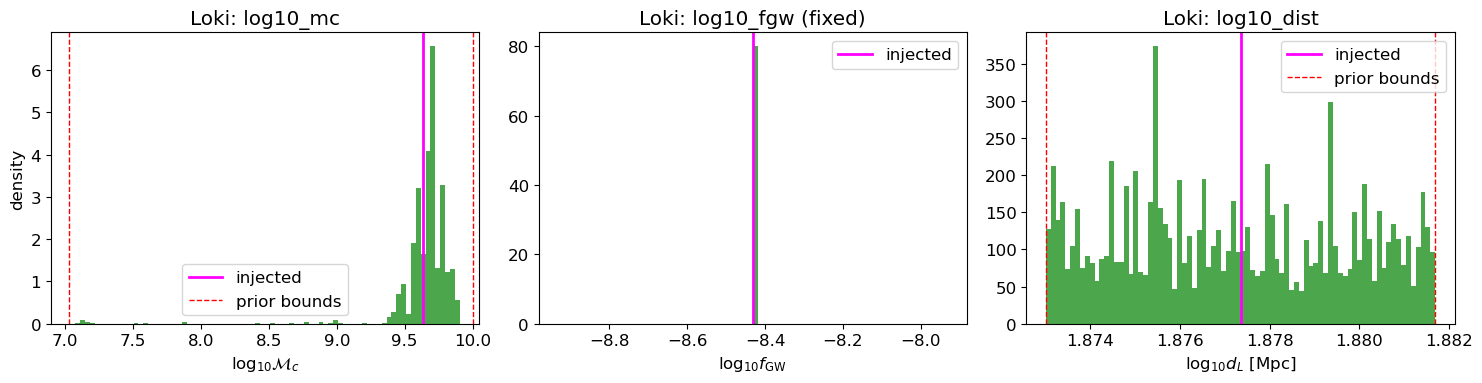

<ipython-input-3-f2f8d3414362>:119: RuntimeWarning: overflow encountered in multiply
  mc_time = mc_solar * M_SUN * G_NEWT / C_LIGHT**3




Loki derived log10_h0:
  range: [-17.9954, inf]
  median: inf
  injected: -13.6688

Sanity check (injecting truth values):
  derive_log10_h0(log10_mc=log10(4.3e9), log10_fgw=log10(3.7e-9), log10_dL=log10(75.4))
  = -13.668773
  Expected: -13.668773
  Difference: -4.94e-07

BIMODALITY INVESTIGATION (Loki)

Loki samples with log10_h0 < -16: 599 / 75000 (0.80%)

For the low log10_h0 cluster:
  log10_mc:   median=7.162, min=7.037, max=8.206
  log10_dist: median=1.8775, min=1.8730, max=1.8817

For the high log10_h0 cluster:
  log10_mc:   median=9.698, min=8.236, max=9.905
  log10_dist: median=1.8771


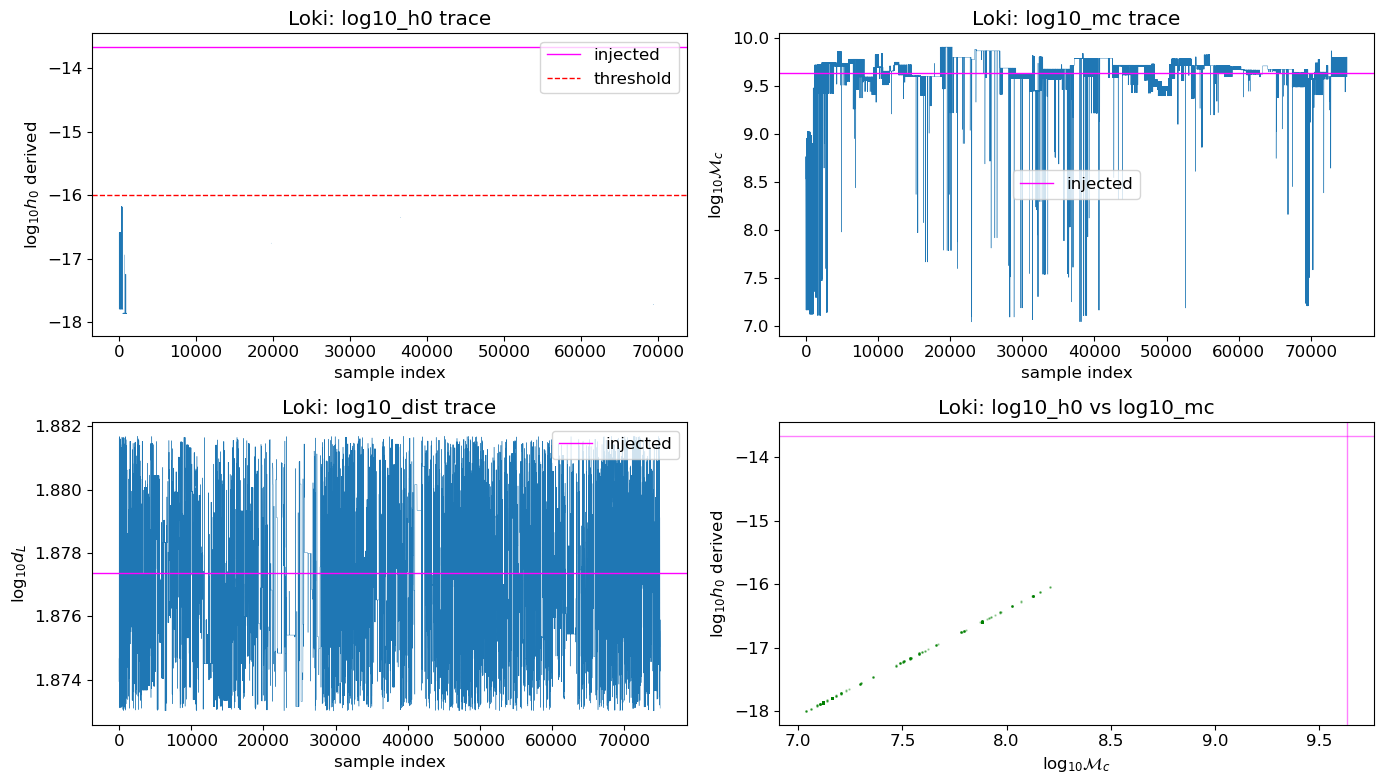


CROSS-PIPELINE log10_mc COMPARISON

My QCW (dL-masked): 126372 samples
  log10_mc:  median=9.672, std=0.132, min=7.033, max=10.048
  log10_h0:  median=-13.606, std=0.220

Loki QCW (direct dL): 75000 samples
  log10_mc:  median=9.694, std=0.245, min=7.037, max=9.905

Enterprise: 72001 samples
  log10_mc:  median=9.679, std=0.122, min=7.199, max=10.045


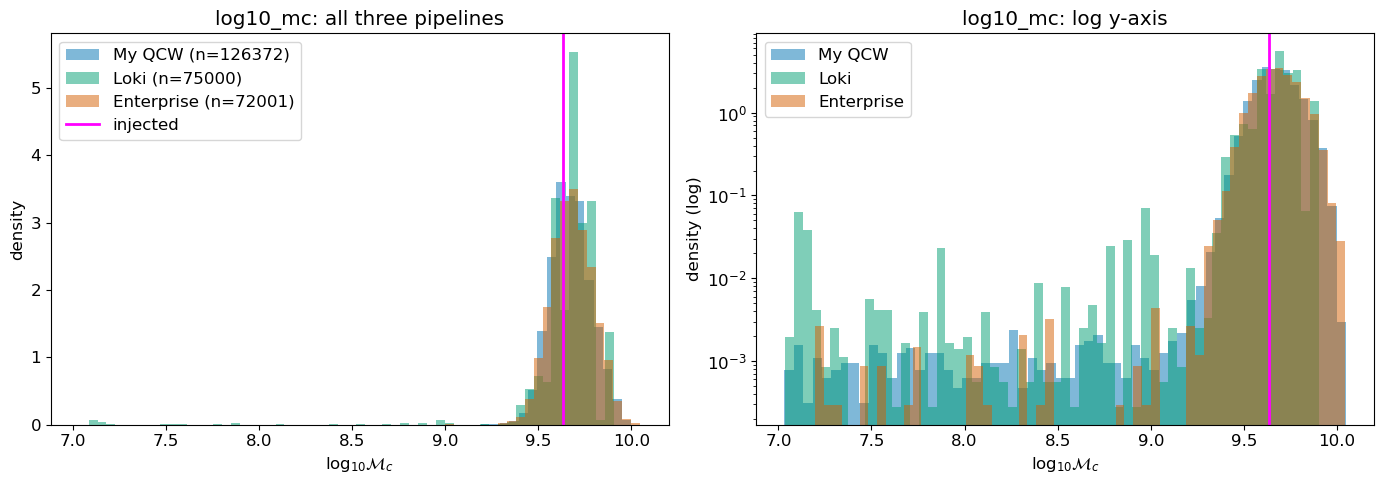

In [3]:
# ============================================================
# Diagnostic: investigate the three pipelines' chains
# Checking why Loki's derived log10_h0 has a low-h0 mode
# ============================================================

%matplotlib inline

import numpy as np
import h5py
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 12


# ============================================================
# Constants and paths
# ============================================================
G_NEWT = 6.67430e-11
C_LIGHT = 2.99792458e8
M_SUN = 1.98840987e30
MPC2M = 3.085677581491367e22

F_GW_FIXED = 3.7e-9
D_MPC_FIXED = 75.400

LOKI_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/"
    "G2D2_fixed_detect_loki_75k_04_May_2026.h5"
)
QCW_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/"
    "G2D2_narrow_detect_dLmasked_75.400Mpc.h5"
)
ENT_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/"
    "core_single_MDC2.h5"
)


# ============================================================
# 1. Inspect Loki chain: raw parameter ranges
# ============================================================
print("="*70)
print("LOKI CHAIN INSPECTION")
print("="*70)

with h5py.File(LOKI_FILE, "r") as f:
    loki_samples = f["samples_cold"][0, :, :]
    loki_par_names = [p.decode() if isinstance(p, bytes) else p
                      for p in f["par_names"][:]]

print(f"\nLoki chain shape: {loki_samples.shape}")
print(f"Total parameters: {len(loki_par_names)}")
print(f"\nCW + GWB parameters:")
for p in loki_par_names:
    if "0_" in p or "gwb" in p:
        idx = loki_par_names.index(p)
        col = loki_samples[:, idx]
        print(f"  {p:30s}: min={col.min():9.4f}, max={col.max():9.4f}, "
              f"median={np.median(col):9.4f}, std={col.std():9.4f}")

# Loki's key derived quantity: log10_h0 from log10_mc, log10_fgw, log10_dist
loki_log10_mc = loki_samples[:, loki_par_names.index("0_log10_mc")]
loki_log10_fgw = loki_samples[:, loki_par_names.index("0_log10_fgw")]
loki_log10_dist = loki_samples[:, loki_par_names.index("0_log10_dist")]

print(f"\nLoki log10_dist range: [{loki_log10_dist.min():.4f}, {loki_log10_dist.max():.4f}]")
print(f"  Expected prior bounds: [{np.log10(74.646):.4f}, {np.log10(76.154):.4f}]")
print(f"  Implied dL range: [{10**loki_log10_dist.min():.3f}, {10**loki_log10_dist.max():.3f}] Mpc")

print(f"\nLoki log10_mc range: [{loki_log10_mc.min():.4f}, {loki_log10_mc.max():.4f}]")
print(f"  Expected prior bounds: [7.03, 10.00]")

print(f"\nLoki log10_fgw range: [{loki_log10_fgw.min():.4f}, {loki_log10_fgw.max():.4f}]")
print(f"  Expected (fixed fGW): {np.log10(F_GW_FIXED):.4f} +/- 1e-21")


# ============================================================
# 2. Plot Loki marginals: log10_mc, log10_fgw, log10_dist
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(loki_log10_mc, bins=80, color="green", alpha=0.7, density=True)
axes[0].axvline(np.log10(4.3e9), color="magenta", lw=2, label="injected")
axes[0].axvline(7.03, color="red", lw=1, ls="--", label="prior bounds")
axes[0].axvline(10.0, color="red", lw=1, ls="--")
axes[0].set_xlabel(r"$\log_{10}\mathcal{M}_c$")
axes[0].set_ylabel("density")
axes[0].legend()
axes[0].set_title("Loki: log10_mc")

axes[1].hist(loki_log10_fgw, bins=80, color="green", alpha=0.7, density=True)
axes[1].axvline(np.log10(3.7e-9), color="magenta", lw=2, label="injected")
axes[1].set_xlabel(r"$\log_{10}f_{\rm GW}$")
axes[1].legend()
axes[1].set_title("Loki: log10_fgw (fixed)")

axes[2].hist(loki_log10_dist, bins=80, color="green", alpha=0.7, density=True)
axes[2].axvline(np.log10(75.4), color="magenta", lw=2, label="injected")
axes[2].axvline(np.log10(74.646), color="red", lw=1, ls="--", label="prior bounds")
axes[2].axvline(np.log10(76.154), color="red", lw=1, ls="--")
axes[2].set_xlabel(r"$\log_{10}d_L$ [Mpc]")
axes[2].legend()
axes[2].set_title("Loki: log10_dist")

plt.tight_layout()
plt.show()


# ============================================================
# 3. Derive Loki log10_h0 step by step, sanity check
# ============================================================
def derive_log10_h0(log10_mc, log10_fgw, log10_dL_Mpc):
    mc_solar = 10.0**log10_mc
    fgw = 10.0**log10_fgw
    dL_Mpc = 10.0**log10_dL_Mpc
    dL_m = dL_Mpc * MPC2M
    mc_time = mc_solar * M_SUN * G_NEWT / C_LIGHT**3
    dL_time = dL_m / C_LIGHT
    h0 = 2.0 * mc_time**(5/3) * (np.pi * fgw)**(2/3) / dL_time
    return np.log10(h0)


loki_log10_h0 = derive_log10_h0(loki_log10_mc, loki_log10_fgw, loki_log10_dist)
print(f"\n\nLoki derived log10_h0:")
print(f"  range: [{loki_log10_h0.min():.4f}, {loki_log10_h0.max():.4f}]")
print(f"  median: {np.median(loki_log10_h0):.4f}")
print(f"  injected: {-13.668773:.4f}")

# Sanity check at injection
h0_check = derive_log10_h0(np.log10(4.3e9), np.log10(3.7e-9), np.log10(75.4))
print(f"\nSanity check (injecting truth values):")
print(f"  derive_log10_h0(log10_mc=log10(4.3e9), log10_fgw=log10(3.7e-9), log10_dL=log10(75.4))")
print(f"  = {h0_check:.6f}")
print(f"  Expected: -13.668773")
print(f"  Difference: {h0_check - (-13.668773):.2e}")


# ============================================================
# 4. Check the bimodality: is it Mc-driven?
# ============================================================
print("\n" + "="*70)
print("BIMODALITY INVESTIGATION (Loki)")
print("="*70)

# Sort by log10_h0 and find low-h0 samples
low_h0_threshold = -16
low_h0_mask = loki_log10_h0 < low_h0_threshold
print(f"\nLoki samples with log10_h0 < {low_h0_threshold}: "
      f"{low_h0_mask.sum()} / {len(loki_log10_h0)} "
      f"({100*low_h0_mask.sum()/len(loki_log10_h0):.2f}%)")

if low_h0_mask.sum() > 0:
    print(f"\nFor the low log10_h0 cluster:")
    print(f"  log10_mc:   median={np.median(loki_log10_mc[low_h0_mask]):.3f}, "
          f"min={loki_log10_mc[low_h0_mask].min():.3f}, "
          f"max={loki_log10_mc[low_h0_mask].max():.3f}")
    print(f"  log10_dist: median={np.median(loki_log10_dist[low_h0_mask]):.4f}, "
          f"min={loki_log10_dist[low_h0_mask].min():.4f}, "
          f"max={loki_log10_dist[low_h0_mask].max():.4f}")
    print(f"\nFor the high log10_h0 cluster:")
    print(f"  log10_mc:   median={np.median(loki_log10_mc[~low_h0_mask]):.3f}, "
          f"min={loki_log10_mc[~low_h0_mask].min():.3f}, "
          f"max={loki_log10_mc[~low_h0_mask].max():.3f}")
    print(f"  log10_dist: median={np.median(loki_log10_dist[~low_h0_mask]):.4f}")


# ============================================================
# 5. Trace plot of Loki log10_h0 to see if chain is exploring or stuck
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(loki_log10_h0, lw=0.3)
axes[0, 0].axhline(-13.668773, color="magenta", lw=1, label="injected")
axes[0, 0].axhline(low_h0_threshold, color="red", lw=1, ls="--", label="threshold")
axes[0, 0].set_xlabel("sample index")
axes[0, 0].set_ylabel(r"$\log_{10}h_0$ derived")
axes[0, 0].set_title("Loki: log10_h0 trace")
axes[0, 0].legend()

axes[0, 1].plot(loki_log10_mc, lw=0.3)
axes[0, 1].axhline(np.log10(4.3e9), color="magenta", lw=1, label="injected")
axes[0, 1].set_xlabel("sample index")
axes[0, 1].set_ylabel(r"$\log_{10}\mathcal{M}_c$")
axes[0, 1].set_title("Loki: log10_mc trace")
axes[0, 1].legend()

axes[1, 0].plot(loki_log10_dist, lw=0.3)
axes[1, 0].axhline(np.log10(75.4), color="magenta", lw=1, label="injected")
axes[1, 0].set_xlabel("sample index")
axes[1, 0].set_ylabel(r"$\log_{10}d_L$")
axes[1, 0].set_title("Loki: log10_dist trace")
axes[1, 0].legend()

# log10_h0 vs log10_mc scatter
axes[1, 1].scatter(loki_log10_mc, loki_log10_h0, s=0.5, alpha=0.3, c="green")
axes[1, 1].axhline(-13.668773, color="magenta", lw=1, alpha=0.5)
axes[1, 1].axvline(np.log10(4.3e9), color="magenta", lw=1, alpha=0.5)
axes[1, 1].set_xlabel(r"$\log_{10}\mathcal{M}_c$")
axes[1, 1].set_ylabel(r"$\log_{10}h_0$ derived")
axes[1, 1].set_title("Loki: log10_h0 vs log10_mc")

plt.tight_layout()
plt.show()


# ============================================================
# 6. Compare Loki Mc vs My QCW Mc vs Enterprise Mc
# ============================================================
print("\n" + "="*70)
print("CROSS-PIPELINE log10_mc COMPARISON")
print("="*70)

with h5py.File(QCW_FILE, "r") as f:
    qc_samples = f["samples_masked"][...]
    qc_par_names = [p.decode() if isinstance(p, bytes) else p
                    for p in f["par_names"][:]]
qc_log10_mc = qc_samples[:, qc_par_names.index("0_log10_mc")]
qc_log10_h = qc_samples[:, qc_par_names.index("0_log10_h")]

with h5py.File(ENT_FILE, "r") as f:
    e_samples_all = f["chain"][...]
    e_par_names = [p.decode() if isinstance(p, bytes) else p
                   for p in f["params"][:]]
    burn = f["metadata/burn"][()]
e_samples = e_samples_all[burn:, :]
ent_log10_mc = e_samples[:, e_par_names.index("log10_mc")]

print(f"\nMy QCW (dL-masked): {qc_log10_mc.shape[0]} samples")
print(f"  log10_mc:  median={np.median(qc_log10_mc):.3f}, std={qc_log10_mc.std():.3f}, "
      f"min={qc_log10_mc.min():.3f}, max={qc_log10_mc.max():.3f}")
print(f"  log10_h0:  median={np.median(qc_log10_h):.3f}, std={qc_log10_h.std():.3f}")

print(f"\nLoki QCW (direct dL): {loki_log10_mc.shape[0]} samples")
print(f"  log10_mc:  median={np.median(loki_log10_mc):.3f}, std={loki_log10_mc.std():.3f}, "
      f"min={loki_log10_mc.min():.3f}, max={loki_log10_mc.max():.3f}")

print(f"\nEnterprise: {ent_log10_mc.shape[0]} samples")
print(f"  log10_mc:  median={np.median(ent_log10_mc):.3f}, std={ent_log10_mc.std():.3f}, "
      f"min={ent_log10_mc.min():.3f}, max={ent_log10_mc.max():.3f}")


# ============================================================
# 7. Side-by-side log10_mc histograms for all three
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(qc_log10_mc, bins=60, alpha=0.5, density=True, color="#0072B2",
             label=f"My QCW (n={len(qc_log10_mc)})")
axes[0].hist(loki_log10_mc, bins=60, alpha=0.5, density=True, color="#009E73",
             label=f"Loki (n={len(loki_log10_mc)})")
axes[0].hist(ent_log10_mc, bins=60, alpha=0.5, density=True, color="#D55E00",
             label=f"Enterprise (n={len(ent_log10_mc)})")
axes[0].axvline(np.log10(4.3e9), color="magenta", lw=2, label="injected")
axes[0].set_xlabel(r"$\log_{10}\mathcal{M}_c$")
axes[0].set_ylabel("density")
axes[0].legend()
axes[0].set_title("log10_mc: all three pipelines")

# Same plot but log y-axis to see tails
axes[1].hist(qc_log10_mc, bins=60, alpha=0.5, density=True, color="#0072B2",
             label="My QCW")
axes[1].hist(loki_log10_mc, bins=60, alpha=0.5, density=True, color="#009E73",
             label="Loki")
axes[1].hist(ent_log10_mc, bins=60, alpha=0.5, density=True, color="#D55E00",
             label="Enterprise")
axes[1].axvline(np.log10(4.3e9), color="magenta", lw=2)
axes[1].set_xlabel(r"$\log_{10}\mathcal{M}_c$")
axes[1].set_ylabel("density (log)")
axes[1].set_yscale("log")
axes[1].legend()
axes[1].set_title("log10_mc: log y-axis")

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# ESS diagnostic: G2D2 fixed fGW
# Mc is the only shape parameter that varies (fGW and dL fixed)
# ============================================================

from emcee import autocorr

def compute_ess(samples):
    try:
        tau = autocorr.integrated_time(samples, quiet=True)[0]
        ess = len(samples) / tau
        return tau, ess
    except Exception:
        return np.nan, np.nan


print("="*70)
print("Effective Sample Size: G2D2 fixed fGW")
print("="*70)
print(f"{'Pipeline':<15} {'Param':<10} {'N raw':<12} {'tau':<10} {'ESS':<10}")
print("-"*70)

for pipe_name, mc, h in [
    ("My QCW",     qc_log10_mc,   qc_log10_h),
    ("Loki",       loki_log10_mc, loki_log10_h0),
    ("Enterprise", ent_log10_mc,  ent_log10_h0),
]:
    tau_mc, ess_mc = compute_ess(mc)
    tau_h,  ess_h  = compute_ess(h)
    print(f"{pipe_name:<15} {'log10_Mc':<10} {len(mc):<12} {tau_mc:<10.1f} {ess_mc:<10.0f}")
    print(f"{pipe_name:<15} {'log10_h0':<10} {len(h):<12} {tau_h:<10.1f} {ess_h:<10.0f}")
    print()

print("="*70)
print("Interpretation")
print("="*70)
print("Loki's point: QCW chains have fewer independent SHAPE parameter samples")
print("than the raw count suggests. ESS > 1000 = well sampled; < 100 = poor.")

Effective Sample Size: G2D2 fixed fGW
Pipeline        Param      N raw        tau        ESS       
----------------------------------------------------------------------
My QCW          log10_Mc   126372       54.8       2304      
My QCW          log10_h0   126372       54.9       2303      

Loki            log10_Mc   75000        948.1      79        
Loki            log10_h0   75000        nan        nan       

Enterprise      log10_Mc   72001        185.8      387       
Enterprise      log10_h0   72001        185.8      387       

Interpretation
Loki's point: QCW chains have fewer independent SHAPE parameter samples
than the raw count suggests. ESS > 1000 = well sampled; < 100 = poor.


/usr/local/anaconda/lib/python3.9/site-packages/emcee/autocorr.py:36: RuntimeWarning: invalid value encountered in subtract
  f = np.fft.fft(x - np.mean(x), n=2 * n)
